# Task 2: Text Chunking, Embedding, and Vector Store Indexing

**Objective:** Convert cleaned complaint narratives into a semantically searchable vector store.

### Steps
1. Load cleaned data from Task 1
2. Create a stratified sample (~2,000 complaints)
3. Chunk narratives with RecursiveCharacterTextSplitter
4. Embed chunks with `all-MiniLM-L6-v2`
5. Persist the vector store to `vector_store/chroma/`

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from src.embedder import (
    stratified_sample, chunk_dataframe, load_embedding_model,
    embed_chunks, build_chroma_store, CHUNK_SIZE, CHUNK_OVERLAP
)

sns.set_theme(style='whitegrid')
%matplotlib inline

c:\Users\loolt\rag-complaint-chatbot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/processed/filtered_complaints.csv')
print(f'Loaded {len(df):,} records')


Loaded 345,805 records


In [3]:
df = df.rename(columns={
    "Date received":                    "date_received",
    "Product":                          "product_category",   # ← this is the key fix
    "Sub-product":                      "sub_product",
    "Issue":                            "issue",
    "Sub-issue":                        "sub_issue",
    "Consumer complaint narrative":     "narrative",
    "Company public response":          "company_public_response",
    "Company":                          "company",
    "State":                            "state",
    "ZIP code":                         "zip_code",
    "Tags":                             "tags",
    "Consumer consent provided?":       "consumer_consent",
    "Submitted via":                    "submitted_via",
    "Date sent to company":             "date_sent_to_company",
    "Company response to consumer":     "company_response",
    "Timely response?":                 "timely_response",
    "Consumer disputed?":               "consumer_disputed",
    "Complaint ID":                     "complaint_id",
    "Product_Family":                   "product_family",
    "cleaned_narrative":                "cleaned_narrative"
})
# Verify
print(df.columns.tolist())
print(df['product_category'].value_counts())


['date_received', 'product_category', 'sub_product', 'issue', 'sub_issue', 'narrative', 'company_public_response', 'company', 'state', 'zip_code', 'tags', 'consumer_consent', 'submitted_via', 'date_sent_to_company', 'company_response', 'timely_response', 'consumer_disputed', 'complaint_id', 'product_family', 'cleaned_narrative']
product_category
Checking or savings account                                140319
Money transfer, virtual currency, or money service          97188
Credit card                                                 80667
Payday loan, title loan, or personal loan                   17238
Payday loan, title loan, personal loan, or advance loan      8896
Money transfers                                              1497
Name: count, dtype: int64


## 2. Stratified Sample

Sample size: 2,001

Category distribution in sample:
product_category
Checking or savings account                                812
Money transfer, virtual currency, or money service         562
Credit card                                                467
Payday loan, title loan, or personal loan                  100
Payday loan, title loan, personal loan, or advance loan     51
Money transfers                                              9
Name: count, dtype: int64


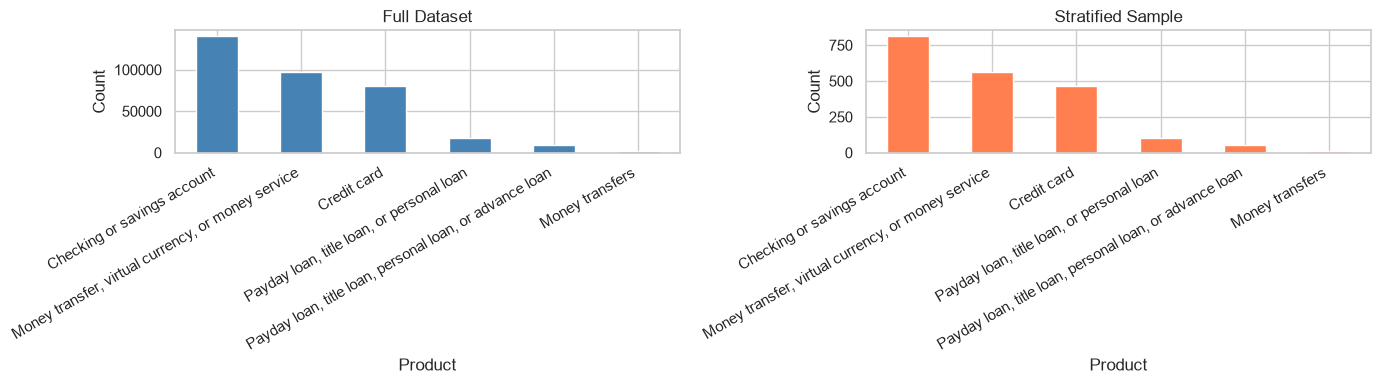

In [4]:
SAMPLE_SIZE = 2000
df_sample = stratified_sample(df, n=SAMPLE_SIZE)
print(f'Sample size: {len(df_sample):,}')
print('\nCategory distribution in sample:')
print(df_sample['product_category'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['product_category'].value_counts().plot(kind='bar', ax=axes[0], title='Full Dataset', color='steelblue')
df_sample['product_category'].value_counts().plot(kind='bar', ax=axes[1], title='Stratified Sample', color='coral')
for ax in axes:
    ax.set_xlabel('Product')
    ax.set_ylabel('Count')
    plt.sca(ax)
    plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/sample_distribution.png', dpi=120)
plt.show()

## Full Dataset vs Stratified Sample
### Overview
The two charts compare the product category distribution between the full dataset and the stratified sample, confirming that the sampling strategy preserved the original proportions faithfully.
| Product Category | Full Dataset (approx.) | Stratified Sample (approx.) |
|---|---|---|
| Checking or savings account | ~140,000 | ~800 |
| Money transfer, virtual currency, or money service | ~95,000 | ~600 |
| Credit card | ~80,000 | ~460 |
| Payday loan, title loan, or personal loan | ~15,000 | ~130 |
| Payday loan, title loan, personal loan, or advance loan | ~9,000 | ~90 |
| Money transfers | ~6,000 | ~60 |

### Key Findings
Dominant category. Checking or savings account complaints are the largest group in both views, accounting for roughly 40–45% of all complaints — making it the most reported product by a significant margin.
Top 3 categories dominate. Checking/savings, money transfer services, and credit card complaints together represent approximately 85% of the dataset, while the remaining three categories make up only ~15%.
Stratification is working correctly. The orange bars mirror the blue bars almost exactly in relative height — this confirms that your stratified sampling preserved the class distribution from the full dataset, which is critical for unbiased model training and evaluation.

